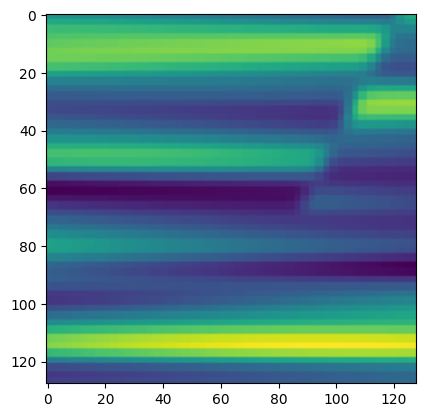

In [2]:
#!/usr/bin/env python
# coding: utf-8

# In[3]:


import matplotlib.pyplot as plt
import numpy as np
from utils import ricker
from tqdm.auto import tqdm
import scipy
from time import time
import torch
import torch.fft as fft
import torch.nn.functional as F

import skimage


# In[7]:


velocities = np.load("../dataset/Density_Test.npy")
nx = 128


# In[8]:


def shape_velocity(v, nx):
    v_2 = scipy.ndimage.zoom(v.reshape((51, 51)), nx/51, order=0)
    return v_2 / v_2.max()


# In[9]:


idx = 4
plt.imshow(shape_velocity(velocities[idx], nx))


# In[12]:


dx = 1.0


# In[41]:


def init(idx, nx, device="mps"):
    nt  = 256
    isx = 1
    isz = nx // 2
    f0  = 15 * 5
    
    c = 300.0 * shape_velocity(velocities[idx], nx)
    c = torch.tensor(c, device=device, dtype=torch.float32)

    dx = 1.0
    dt = 0.001
    
    shape = (nx, nx)
    zeros = lambda: torch.zeros(shape, device=device, dtype=torch.float32)

    ap    = zeros()
    apnew = zeros()
    apold = zeros()
    ad2px = zeros()
    ad2pz = zeros()

    sp    = zeros()
    spnew = zeros()
    spold = zeros()
    sd2px = zeros()
    sd2pz = zeros()
    
    t = torch.arange(1, nt+1, device=device) * dt
    T0 = 1.0 / (15 * 5)

    tmp = torch.diff(torch.tensor(ricker(dt, T0), device=device, dtype=torch.float32)) * 1e7
    src = torch.zeros(nt, device=device, dtype=torch.float32)
    src[:tmp.numel()] = tmp

    lam = c * T0
    
    x = torch.arange(nx, device=device) * dx
    z = x.clone()

    sigma = 1.5 * dx
    x0, z0 = x[isx], z[isz]

    xx = x[:, None]
    zz = z[None, :]

    sg = torch.exp(-((xx - x0)**2 + (zz - z0)**2) / sigma**2)
    sg = sg / sg.max()

    return (nt, c, ap, apnew, apold, ad2px, ad2pz, dx, dt, src, sg)


# The final solution for our 2D acoustic wave problem after taking into account the finite differences time extrapolation can be written as
# 
# $$\begin{equation} p_{j,k}^{n+1} = dt^2c_{j,k}^{2} (\partial_{x}^{2}p + \partial_{z}^{2}p){j,k} + dt^2s{j,k}^{n} + 2p_{j,k}^{n} - p_{j,k}^{n-1} \end{equation}$$
# 
# In order to compare the above numerical solution, we implement a 5-point finite difference operator to compute spatial derivatives
# 
# $$\begin{equation} \partial_t^2 p(x,t) = \frac{-p(x,t+2\mathrm{d}t) + 16p(x,t+\mathrm{d}t) - 30p(x,t) + 16p(x,t-\mathrm{d}t) - p(x,t-2\mathrm{d}t)}{12\mathrm{d}t^2} \end{equation}$$
# 
# temporal derivative is done with a 3-point finite difference operator.

# In[42]:


kx = 2 * torch.pi * torch.fft.fftfreq(nx, d=dx, device="mps")
kx2 = -(kx**2).reshape(-1, 1)
kz2 = -(kx**2).reshape(1, -1)

#@torch.compile
def spectral_step(sp, spold, c, dt, sg, src, it):
    sp_fft = fft.fft2(sp)
    return sp, 2*sp - spold + c**2 * dt**2 * (fft.ifft2(sp_fft * kx2).real + fft.ifft2(sp_fft * kz2).real) + sg * src[it] * dt**2
    
#@torch.compile
def fd_step(ap, apold, c, dt, dx, sg, src, it):
    return ap, 2*ap - apold + c**2 * dt**2 * (
            ((-torch.roll(ap, -2, dims=0) + 16 * torch.roll(ap, -1, dims=0) - 30 * ap + 16 * torch.roll(ap,  1, dims=0) - torch.roll(ap,  2, dims=0)) / (12 * dx**2))
            + (( - torch.roll(ap, -2, dims=1) + 16 * torch.roll(ap, -1, dims=1) - 30 * ap + 16 * torch.roll(ap,  1, dims=1) - torch.roll(ap,  2, dims=1)) / (12 * dx**2))
        ) + sg * src[it] * dt**2


# In[43]:


import torch.nn.functional as F

def laplacian_2d(u, dx=1.0):
    kernel = torch.tensor(
        [[[
            [0.,    0.,   -1.,    0.,    0.],
            [0.,   16.,    0.,   16.,    0.],
            [-1.,   0.,  -60.,    0.,   -1.],
            [0.,   16.,    0.,   16.,    0.],
            [0.,    0.,   -1.,    0.,    0.],
        ]]],
        device=u.device, dtype=u.dtype
    )

    x = u.unsqueeze(1)    
    x_padded = F.pad(x, pad=(2, 2, 2, 2), mode='circular')
    lap = F.conv2d(x_padded, kernel, padding=0) / (12.0 * dx**2)

    return lap.squeeze(1)

def loss_fn(u_prev, u_curr, u_pred, c, dt, dx):
    u_tt = (u_pred - 2.0 * u_curr + u_prev) / (dt ** 2)
    lap_u = laplacian_2d(u_curr, dx=dx)
    c2 = c ** 2
    R = u_tt - c2 * lap_u
    loss = (R ** 2).mean()
    return loss**0.5


# In[45]:


In [3]:
def downsample(c, n):
    x = skimage.transform.rescale(skimage.transform.rescale(c, 1/n), n)
    return torch.tensor(x)

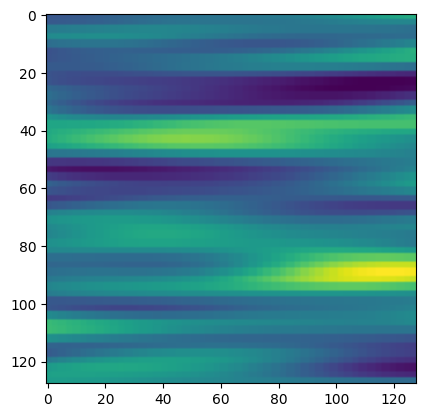

In [4]:
plt.imshow(shape_velocity(velocities[0], nx))

In [5]:
def get_traces(idx, nx, device="mps"):
    (nt, c, ap, apnew, apold, ad2px, ad2pz, dx, dt, src, sg) = init(idx, nx, device=device)

    ap_div_2, apnew_div_2, apold_div_2, ad2px_div_2, ad2pz_div_2 = ap.clone(), apnew.clone(), apold.clone(), ad2px.clone(), ad2pz.clone()
    ap_div_4, apnew_div_4, apold_div_4, ad2px_div_4, ad2pz_div_4 = ap.clone(), apnew.clone(), apold.clone(), ad2px.clone(), ad2pz.clone()
    ap_div_8, apnew_div_8, apold_div_8, ad2px_div_8, ad2pz_div_8 = ap.clone(), apnew.clone(), apold.clone(), ad2px.clone(), ad2pz.clone()

    trace_fd_div_8 = []
    trace_fd_div_4 = []
    trace_fd_div_2 = []
    trace_fd = []

    c_div_2 = (downsample(c.cpu().numpy(), 2)).to(device)
    c_div_4 = (downsample(c.cpu().numpy(), 4)).to(device)
    c_div_8 = (downsample(c.cpu().numpy(), 8)).to(device)
    
    for it in range(nt):
        apold_div_2, ap_div_2 = fd_step(ap_div_2, apold_div_2, c_div_2, dt, dx, sg, src, it)
        trace_fd_div_2.append(ap_div_2[0].detach().cpu())

        apold_div_4, ap_div_4 = fd_step(ap_div_4, apold_div_4, c_div_4, dt, dx, sg, src, it)
        trace_fd_div_4.append(ap_div_4[0].detach().cpu())

        apold_div_8, ap_div_8 = fd_step(ap_div_8, apold_div_8, c_div_8, dt, dx, sg, src, it)
        trace_fd_div_8.append(ap_div_8[0].detach().cpu())

        apold, ap = fd_step(ap, apold, c, dt, dx, sg, src, it)
        trace_fd.append(ap[0].detach().cpu())
        
    return (
        torch.stack(trace_fd_div_2),
        torch.stack(trace_fd_div_4),
        torch.stack(trace_fd_div_8),
        torch.stack(trace_fd),
        nt, dt, c.cpu(), nx, dx
    )

velocities = np.load("../dataset/Density_Test.npy")
nx = 128


# In[181]:


y, x_div_2, x_div_4, x_div_8 = [], [], [], []
cs = []
for idx in tqdm(range(velocities.shape[0])):
    trace_div_2, trace_div_4, trace_div_8, trace, nt, dt, c, nx, dx = get_traces(idx, nx)
    y.append(trace.clone())
    x_div_2.append(trace_div_2.clone())
    x_div_4.append(trace_div_4.clone())
    x_div_8.append(trace_div_8.clone())
    cs.append(c.clone())


# In[182]:


torch.save(torch.stack(y), "y_fd_test.pt")
torch.save(torch.stack(x_div_2), "x_div_2_test.pt")
torch.save(torch.stack(x_div_4), "x_div_4_test.pt")
torch.save(torch.stack(x_div_8), "x_div_8_test.pt")
torch.save(torch.stack(cs), "c_fd_test.pt")
print("Done")

  0%|          | 0/1000 [00:00<?, ?it/s]

Done


In [6]:
velocities = np.load("../dataset/Density_Train.npy")
nx = 128


# In[181]:


y, x_div_2, x_div_4, x_div_8 = [], [], [], []
cs = []
for idx in tqdm(range(10000)):
    trace_div_2, trace_div_4, trace_div_8, trace, nt, dt, c, nx, dx = get_traces(idx, nx)
    y.append(trace.clone())
    x_div_2.append(trace_div_2.clone())
    x_div_4.append(trace_div_4.clone())
    x_div_8.append(trace_div_8.clone())
    cs.append(c.clone())


# In[182]:


torch.save(torch.stack(y), "y_fd_train.pt")
torch.save(torch.stack(x_div_2), "x_div_2_train.pt")
torch.save(torch.stack(x_div_4), "x_div_4_train.pt")
torch.save(torch.stack(x_div_8), "x_div_8_train.pt")
torch.save(torch.stack(cs), "c_fd_train.pt")
print("Done")

  0%|          | 0/10000 [00:00<?, ?it/s]

Done


In [7]:
y, x_div_2, x_div_4, x_div_8 = [], [], [], []
cs = []
for idx in tqdm(range(10000, velocities.shape[0])):
    trace_div_2, trace_div_4, trace_div_8, trace, nt, dt, c, nx, dx = get_traces(idx, nx)
    y.append(trace.clone())
    x_div_2.append(trace_div_2.clone())
    x_div_4.append(trace_div_4.clone())
    x_div_8.append(trace_div_8.clone())
    cs.append(c.clone())


# In[182]:


torch.save(torch.stack(y), "y_fd_train_2.pt")
torch.save(torch.stack(x_div_2), "x_div_2_train_2.pt")
torch.save(torch.stack(x_div_4), "x_div_4_train_2.pt")
torch.save(torch.stack(x_div_8), "x_div_8_train_2.pt")
torch.save(torch.stack(cs), "c_fd_train_2.pt")
print("Done")

  0%|          | 0/17000 [00:00<?, ?it/s]

Done
